# Contributions
## Hai, Vinay, Su
**Note**
- Common functions were shared and used across all model implementations.
- Shared functions were reviewed and approved by members of the DL branch before being refactored for reusability.
- All members participated in results analysis.

# Import libraries

In [47]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import os
import matplotlib.pyplot as plt
from torchvision.models import EfficientNet_B0_Weights

# Data preparation

## Load data

In [49]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Each of the following corresponds to the given 5 batches of data from CIFAR10
# Batches 1-5 are used as training materials, while testing would be conducted solely on the test batch
batch1 = unpickle("cifar-10-batches-py/data_batch_1")
batch2 = unpickle("cifar-10-batches-py/data_batch_2")
batch3 = unpickle("cifar-10-batches-py/data_batch_3")
batch4 = unpickle("cifar-10-batches-py/data_batch_4")
batch5 = unpickle("cifar-10-batches-py/data_batch_5")
test_batch = unpickle("cifar-10-batches-py/test_batch")

# We examine the type of data of each batch. It turns out that the data of the batch is stored in a nump array.
print(type(batch1))
print(batch1.keys())
print(type(batch1[b'data']))

# A label mask dictionary was initiated to assist with downstream result analysis, by assigning label strings to integers
label_mask = {}
metadata = unpickle("cifar-10-batches-py/batches.meta")
for i, label in enumerate(metadata[b"label_names"]):
    label_mask[i] = label.decode("utf-8")

# To combine the batches, we concatenate each data array into a singular array
X = np.concatenate([
    batch1[b'data'],
    batch2[b'data'],
    batch3[b'data'],
    batch4[b'data'],
    batch5[b'data']
], axis=0)

# The same thing was done for the target array
y = np.concatenate([
    batch1[b'labels'],
    batch2[b'labels'],
    batch3[b'labels'],
    batch4[b'labels'],
    batch5[b'labels']
], axis=0)

# Examining the X and y shapes, we have to reconfigure them to suit PyTorch syntax
# 3072 = 32*32*3
# We have to reshape the data to (num_samples, 3, 32, 32) for PyTorch
print(X.shape)
print(y.shape)

# The dataset was then split into training and validation sets at 80%/20% respectively. Random state = 42 was used to ensure 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test, y_test = np.array(test_batch[b'data']), np.array(test_batch[b'labels'])

<class 'dict'>
dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
<class 'numpy.ndarray'>
(50000, 3072)
(50000,)


## Custom dataset

In [51]:
# torchvision transforms expect image files (e.g., PIL images), yet our data are numpy arrays
# According to CIFAR-10 data format, each sample contains 3072 values arranged as [R(1024), G(1024), B(1024)], 
# Therefore, this custom dataset transforms them into a valid PIL Image (provided by Pillow - Python Imaging Library))  for downstream processing
class CIFAR10ArrayDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]

        # Convert from (3072,) -> (3, 32, 32) -> (32, 32, 3)
        # Like from 3072 => 3x1024 => 3x32x32 => 32x32x3
        img = img.reshape(3, 32, 32).transpose(1, 2, 0)

        # Convert numpy image to PIL image for torchvision transforms
        img = Image.fromarray(img.astype(np.uint8))

        label = int(self.y[idx])

        if self.transform:
            img = self.transform(img)

        return img, label

## Normalisation

In [53]:
# ImageNet-based normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# The baseline CNN was not pretrained and would be trained from scratch
# Therefore, CNN normalisation values are computed from the training set
X_train_reshaped = X_train.reshape(-1, 3, 32, 32) / 255.0
CNN_MEAN = X_train_reshaped.mean(axis=(0, 2, 3))
CNN_STD = X_train_reshaped.std(axis=(0, 2, 3))

## Data augmentation

In [29]:
# This function applies several visual transformations to the training data.
# The idea is to provide more visual variations and diversity in order to boost generalisation and reduce overfitting
# Parameters are custom and configurable to accomodate models with different input sizes and nomralisation requirements
def train_data_aug(mean, std, size, padding):
    return transforms.Compose([
        # Resize for pretrained models
        transforms.Resize((size,size)),
        # Random horizontal flip
        transforms.RandomHorizontalFlip(p=0.5),
    
        # Random color jitter
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1
        ),
    
        # Random rotations
        transforms.RandomRotation(10),
    
        # Random crop
        transforms.RandomCrop(size, padding=padding),
    
        transforms.ToTensor(),
    
        # Normalize using the mean and std of the pretrained model (e.g., ImageNet, ResNet, etc...)
        transforms.Normalize(mean, std)
    ])

# This data augmentation function only apply deterministic preprocessing to the validation and test sets
# No augmentation is applied besides resizing and normalisation to ensure model evaluation is consistent and accurate
def val_data_aug(mean, std, size):
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

# Training

## Training device

In [55]:
# Leveraging GPU server if available for more efficient training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## General functions

### Training and validation function

In [ ]:
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        # loss.item() gives the average loss for the batch, we multiply by batch size to get total loss for the batch, then we will divide by total samples at the end to get average loss per sample
        train_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()

        # We add the batch size to the total count of samples seen so far
        train_total += labels.size(0)

    train_loss = train_loss / train_total
    train_correct = train_correct / train_total
    return train_loss, train_correct


# Set model to evaluation mode to disable training-specific layers
def evaluate(model, val_loader, criterion):
    model.eval()
    eval_loss, eval_correct, eval_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            eval_correct += (preds == labels).sum().item()

            eval_total += labels.size(0)
    
    # Calculate average validation loss across the entire dataset
    # Calculate overall validation accuracy
    eval_loss = eval_loss / eval_total
    eval_correct = eval_correct / eval_total    
    
    #Print validation loss and accuracy
    return eval_loss, eval_correct

### Plot curve function

In [ ]:
# Display model learning curve for training and validation sets across epochs
def plot_train_val_curve(range_values, train_value, val_value, label, title, file_name):
    plt.figure(figsize=(8, 5))
    plt.plot(range_values, train_value, label=f"Training {label}")
    plt.plot(range_values, val_value, label=f"Validation {label}")
    plt.xlabel("Epoch")
    plt.ylabel(label)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

### Test evaluation function

In [ ]:
# Set model to evaluation mode (disables dropout, batch norm updates, etc.)

def test_evaluation(model, test_loader, label_mask, mean, std):
    model.eval()
    test_preds = []
    test_labels = []

    # Empty arrays to store information for sample images with their ground truth labels and predictions
    sample_images = []
    sample_preds = []
    sample_truths = []

    # Disable gradient calculations to reduce memory usage and speed up inference
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
    
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
    
            test_preds.extend(predicted.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())
            
            sample_images.extend(images.cpu())
            sample_preds.extend(predicted.cpu().numpy())
            sample_truths.extend(labels.cpu().numpy())

    # Calculate evaluation metrics
    accuracy = accuracy_score(test_labels, test_preds)
    precision = precision_score(test_labels, test_preds, average='macro')
    recall = recall_score(test_labels, test_preds, average='macro')
    f1 = f1_score(test_labels, test_preds, average='macro')

    # Display overall model performance metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Generate classification report for each class
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=list(label_mask.values())))
    cm = confusion_matrix(test_labels, test_preds)

    class_names = list(label_mask.values())
    
    # Visualise confusion matrix as a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Test Set)")
    plt.show()

    # The rng variable stores a numpy random generator, which will be used to generate random sample examples
    # Seed = 42 to ensure reproducibility
    rng = np.random.default_rng(seed=42)

    # A random set of indices are chosen from the generator based on sample_images
    indices = rng.choice(len(sample_images), size=12, replace=False)
    fig, axes = plt.subplots(4, 3, figsize=(10, 14))
    
    # Improve height padding for better visualisation 
    plt.subplots_adjust(hspace=0.8)
    axes = axes.flatten()
    
    for ax, idx in zip(axes, indices):
        img = sample_images[idx]
        # Convert (rgb, height, width) -> (height, widhth, channels) for appropriate visualisation
        img = img.permute(1, 2, 0).numpy()
        # Denormalisation
        img = img * std + mean
        img = np.clip(img, 0, 1)
    
        true_label = label_mask[sample_truths[idx]]
        pred_label = label_mask[sample_preds[idx]]
    
        ax.imshow(img)

        # Renders labels and predictions below the image for better visualisation
        ax.set_xlabel(
            f"True label: {true_label}\nPrediction: {pred_label}",
            fontsize=10,
            labelpad=10
        )
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.suptitle("Random Test Predictions")
    plt.tight_layout()
    plt.show()


## CNN

### Data loader

In [109]:
train_transform = train_data_aug(CNN_MEAN, CNN_STD, 32, 4)
val_transform = val_data_aug(CNN_MEAN, CNN_STD, 32)

train_dataset = CIFAR10ArrayDataset(X_train, y_train, transform=train_transform)
val_dataset = CIFAR10ArrayDataset(X_val, y_val, transform=val_transform)
test_dataset = CIFAR10ArrayDataset(X_test, y_test, transform=val_transform)

# DataLoaders were used on each split, to load data in batches of 64, which improves training efficiency and memory utilisation
# Shuffle was used to make sure the training process is not biased towards sample ordering to improve generalisation
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

# Validation 
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
)

# Test
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

### Model

In [111]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Input (64, 3, 32, 32)
            # 64 batch size, 3 channels, 32x32 image size
            # Padding = 1 to maintain spatial dimensions after convolution (32x32 -> 32x32) since the filter does not operate on the borders.
            # If no padding, the spatial dimensions would reduce after each convolution (32x32 -> 30x30), 
            # which would lead to very small feature maps after a few layers, 
            # and we might lose important spatial information. 
            # By using padding=1, we ensure that the output feature maps have the same spatial dimensions as the input, 
            # allowing us to stack more convolutional layers without reducing the feature map size too quickly.
            nn.Conv2d(3, 32, kernel_size=3, padding=1),

            # BatchNorm was used to normalise the activations within a batch, 
            # helping stabilise training and allowing the models to converge more efficiently, 
            nn.BatchNorm2d(32),

            # To prevent the model from becoming too linear, the ReLU activation was used to render the value x into max(0,x)
            # By reducing all the negative values to 0, the model treats negative and positive values differently
            # which forces the model to make more complex relationships
            nn.ReLU(),

            # Finally, a MaxPool2D layer was added to improve efficiency as feature maps enlarge. 
            # For example, earlier in this model, the convolutional layer increased the value size from (64,3,32,32) to (64,32,32,32). 
            # MaxPool2D offsets this by retaining the most important activations from regions of each feature map, then collapsing them
            # and reducing spatial dimensions, which improves computational efficiency
            nn.MaxPool2d(2),   # 32 -> 16

            # Output of previous layer is (64, 32, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16 -> 8
            
            # Output of previous layer is (64, 64, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 8 -> 4
        )
        
        self.classifier = nn.Sequential(
            # Output of previous layer is (64, 128, 4, 4)
            nn.Flatten(),
            # Output of previous layer is (64, 128*4*4) = (64, 2048)
            nn.Linear(128 * 4 * 4, 256),
            # Output of previous layer is (64, 256)
            nn.ReLU(),
            # Regularization to prevent overfitting, randomly zero out 30% of the activations during training
            nn.Dropout(0.3),
            # Output of previous layer is (64, 256)
            nn.Linear(256, num_classes)
            # Output of previous layer is (64, num_classes) => (64, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
model = BaselineCNN(num_classes=10).to(device)

### Training

In [28]:
# Common loss function used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimiser with lr = 0.001
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
best_val_acc, best_epoch = 0.0, 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_path = 'best_cnn.pth'

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

print(f"Best epoch: {best_epoch}/{num_epochs}, Validation Accuracy: {best_val_acc}")

Epoch 1/10 | Train Loss: 1.5891 | Train Acc: 0.4132 | Val Loss: 1.2065 | Val Acc: 0.5590
Epoch 2/10 | Train Loss: 1.2957 | Train Acc: 0.5288 | Val Loss: 1.0146 | Val Acc: 0.6324
Epoch 3/10 | Train Loss: 1.1566 | Train Acc: 0.5855 | Val Loss: 0.9609 | Val Acc: 0.6553
Epoch 4/10 | Train Loss: 1.0784 | Train Acc: 0.6149 | Val Loss: 0.9108 | Val Acc: 0.6821
Epoch 5/10 | Train Loss: 1.0221 | Train Acc: 0.6387 | Val Loss: 0.8231 | Val Acc: 0.7115
Epoch 6/10 | Train Loss: 0.9672 | Train Acc: 0.6577 | Val Loss: 0.7736 | Val Acc: 0.7284
Epoch 7/10 | Train Loss: 0.9304 | Train Acc: 0.6708 | Val Loss: 0.7870 | Val Acc: 0.7218
Epoch 8/10 | Train Loss: 0.9038 | Train Acc: 0.6812 | Val Loss: 0.7396 | Val Acc: 0.7392
Epoch 9/10 | Train Loss: 0.8739 | Train Acc: 0.6926 | Val Loss: 0.7804 | Val Acc: 0.7240
Epoch 10/10 | Train Loss: 0.8503 | Train Acc: 0.7007 | Val Loss: 0.6882 | Val Acc: 0.7570
Best epoch: 10/10, Validation Accuracy: 0.757


### Evaluation

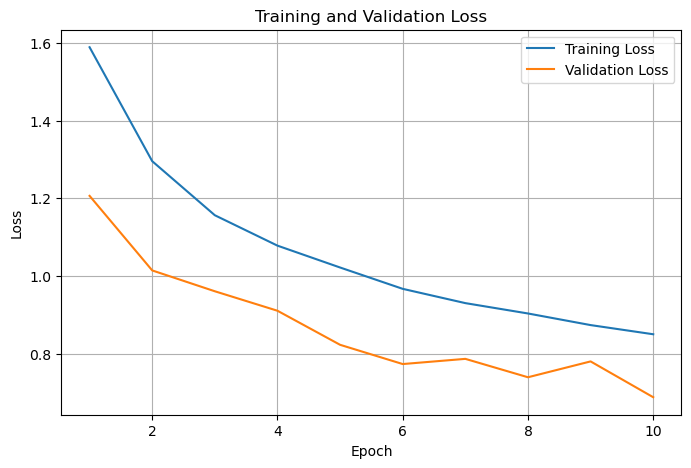

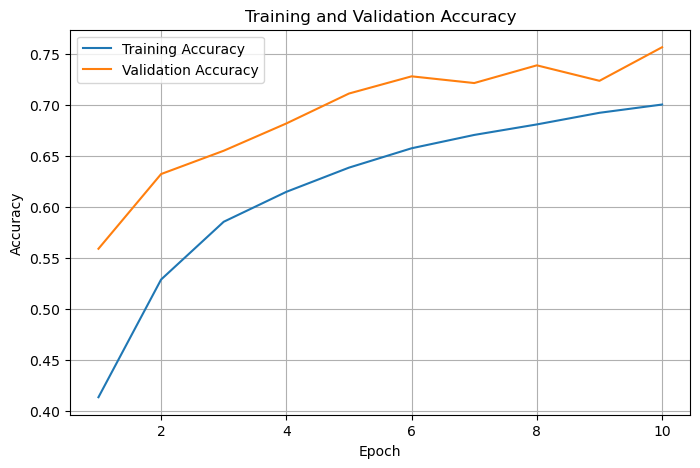

In [30]:
plot_train_val_curve(
    range(1,num_epochs+1), 
    history['train_loss'],
    history['val_loss'], 
    "Loss", 
    "Training and Validation Loss", 
    "cnn_loss_curve.png"
)

plot_train_val_curve(
    range(1,num_epochs+1), 
    history['train_acc'],
    history['val_acc'], 
    "Accuracy", 
    "Training and Validation Accuracy", 
    "cnn_acc_curve.png"
)

Accuracy: 0.7557
Precision: 0.7581
Recall: 0.7557
F1-score: 0.7537

Classification Report:
              precision    recall  f1-score   support

    airplane       0.78      0.76      0.77      1000
  automobile       0.88      0.89      0.88      1000
        bird       0.66      0.61      0.63      1000
         cat       0.63      0.50      0.56      1000
        deer       0.65      0.79      0.71      1000
         dog       0.67      0.67      0.67      1000
        frog       0.71      0.89      0.79      1000
       horse       0.88      0.74      0.81      1000
        ship       0.85      0.89      0.87      1000
       truck       0.88      0.82      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



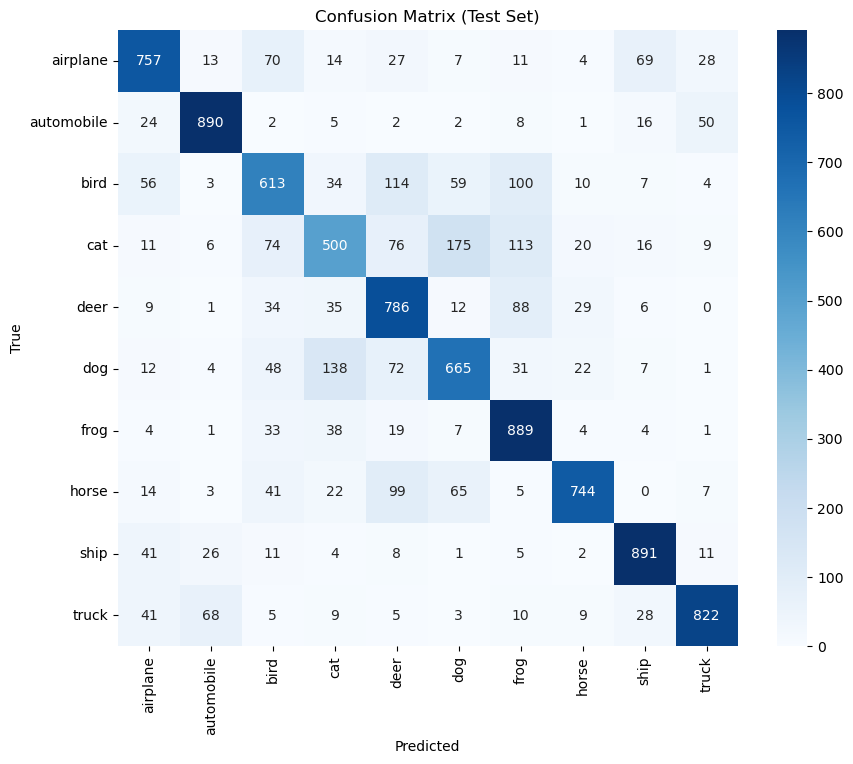

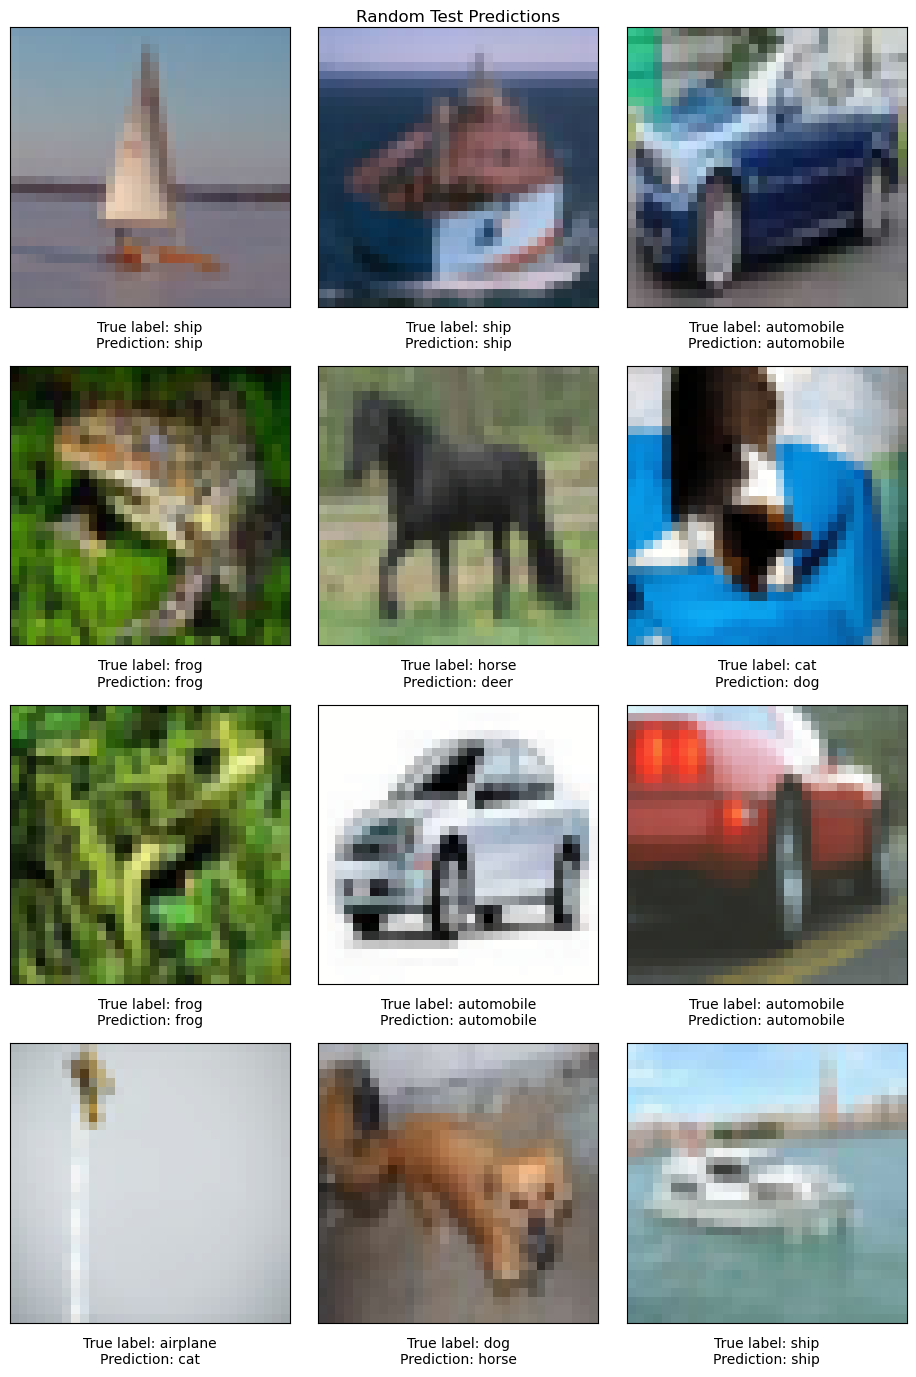

In [118]:
best_model_path = 'best_cnn.pth'
model.load_state_dict(torch.load(best_model_path))
test_evaluation(model, test_loader, label_mask, CNN_MEAN, CNN_STD) 

## ResNet

### Data loader

In [ ]:
# Set up training and validation image transforms (augmentation for train only)
train_transform = train_data_aug(IMAGENET_MEAN, IMAGENET_STD, 224, 16)
val_transform = val_data_aug(IMAGENET_MEAN, IMAGENET_STD, 224)

# Create dataset objects for train/val/test splits
train_dataset = CIFAR10ArrayDataset(X_train, y_train, transform=train_transform)
val_dataset = CIFAR10ArrayDataset(X_val, y_val, transform=val_transform)
test_dataset = CIFAR10ArrayDataset(X_test, y_test, transform=val_transform)

# DataLoader for training (shuffled each epoch)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

# DataLoader for validation (no shuffling)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
)

# DataLoader for final testing (no shuffling)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

### Model

In [ ]:
# Load pretrained ResNet‑18 model with ImageNet weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Unfreeze all layers so the entire network is trainable end‑to‑end
for param in model.parameters():
    param.requires_grad = True

# Replace the final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

model = model.to(device)

# Optimizer updates ALL parameters
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Use cross‑entropy loss for multi‑class classification
criterion = nn.CrossEntropyLoss()

### Training

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Set number of epochs and tracking variables
num_epochs = 10
best_val_acc, best_epoch = 0.0, 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_path = 'best_resnet.pth'

# Training loop: train + validate each epoch
for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

# Store metrics for plotting later
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

  # Save model if this epoch has the best validation accuracy so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), best_model_path)

# Print progress for this epoch
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

# Report the best-performing epoch
print(f"Best epoch: {best_epoch}/{num_epochs}, Validation Accuracy: {best_val_acc}")

Epoch 1/10 | Train Loss: 0.3847 | Train Acc: 0.8719 | Val Loss: 0.2254 | Val Acc: 0.9233
Epoch 2/10 | Train Loss: 0.1795 | Train Acc: 0.9405 | Val Loss: 0.1674 | Val Acc: 0.9409
Epoch 3/10 | Train Loss: 0.1284 | Train Acc: 0.9563 | Val Loss: 0.1790 | Val Acc: 0.9400
Epoch 4/10 | Train Loss: 0.1012 | Train Acc: 0.9646 | Val Loss: 0.1669 | Val Acc: 0.9457
Epoch 5/10 | Train Loss: 0.0797 | Train Acc: 0.9721 | Val Loss: 0.1555 | Val Acc: 0.9494
Epoch 6/10 | Train Loss: 0.0690 | Train Acc: 0.9772 | Val Loss: 0.1645 | Val Acc: 0.9474
Epoch 7/10 | Train Loss: 0.0615 | Train Acc: 0.9788 | Val Loss: 0.1793 | Val Acc: 0.9444
Epoch 8/10 | Train Loss: 0.0527 | Train Acc: 0.9826 | Val Loss: 0.2111 | Val Acc: 0.9391
Epoch 9/10 | Train Loss: 0.0523 | Train Acc: 0.9821 | Val Loss: 0.1551 | Val Acc: 0.9538
Epoch 10/10 | Train Loss: 0.0444 | Train Acc: 0.9846 | Val Loss: 0.1709 | Val Acc: 0.9507
Best epoch: 9/10, Validation Accuracy: 0.9538


### Evaluation

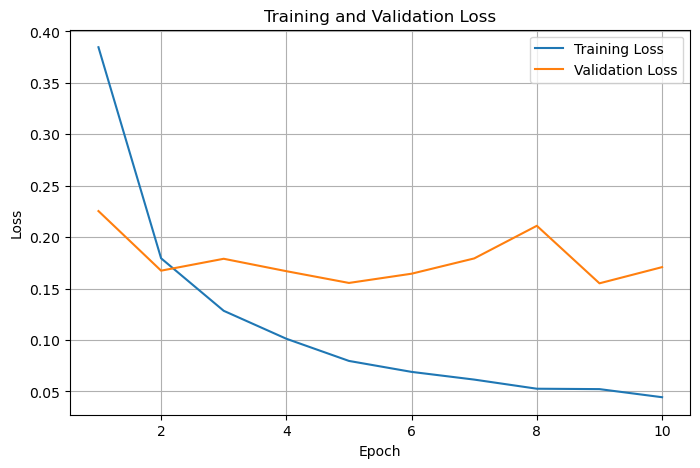

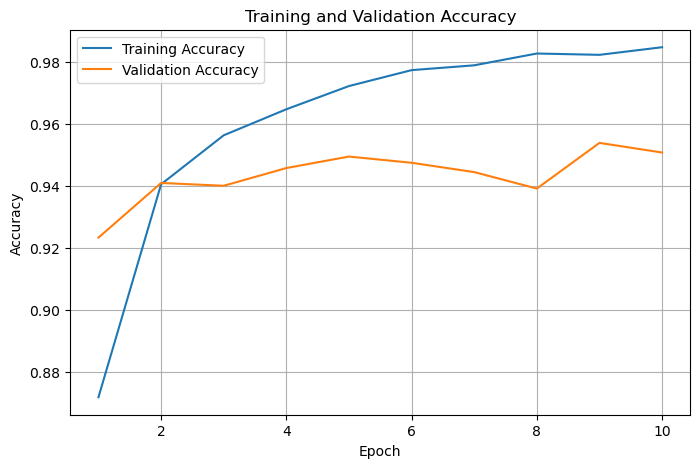

In [ ]:
# Plot training vs validation loss across all epochs
plot_train_val_curve(
    range(1,num_epochs+1), 
    history['train_loss'],
    history['val_loss'], 
    "Loss", 
    "Training and Validation Loss", 
    "resnet_loss_curve.png"
)

# Plot training vs validation accuracy across all epochs
plot_train_val_curve(
    range(1,num_epochs+1), 
    history['train_acc'],
    history['val_acc'], 
    "Accuracy", 
    "Training and Validation Accuracy", 
    "resnet_acc_curve.png"
)

Accuracy: 0.9465
Precision: 0.9469
Recall: 0.9465
F1-score: 0.9465

Classification Report:
              precision    recall  f1-score   support

    airplane       0.94      0.95      0.94      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.94      0.95      0.94      1000
         cat       0.91      0.86      0.88      1000
        deer       0.97      0.94      0.95      1000
         dog       0.88      0.93      0.90      1000
        frog       0.98      0.96      0.97      1000
       horse       0.95      0.97      0.96      1000
        ship       0.97      0.97      0.97      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



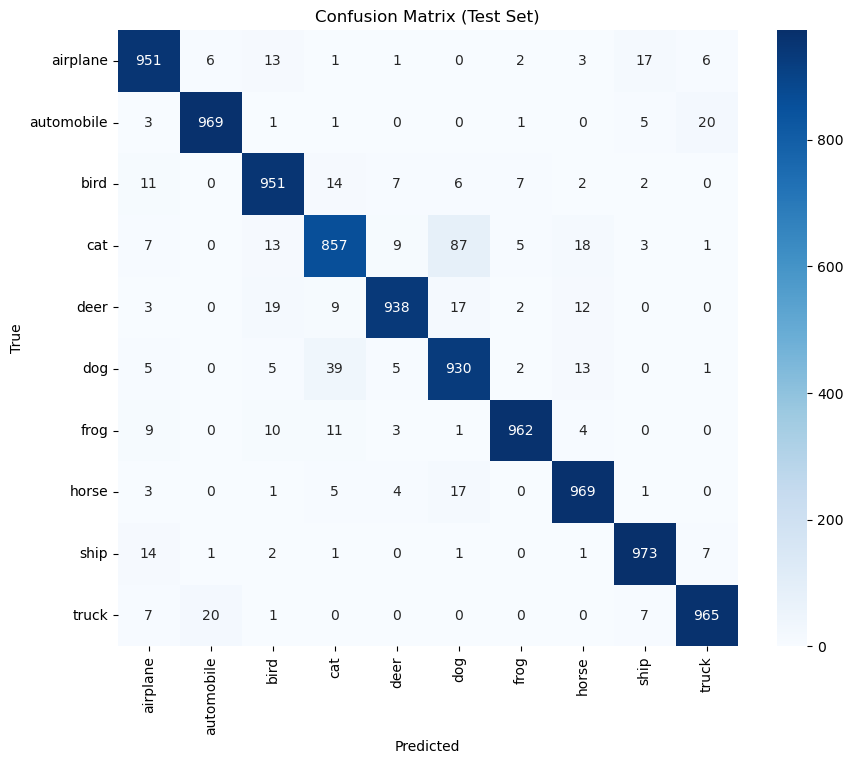

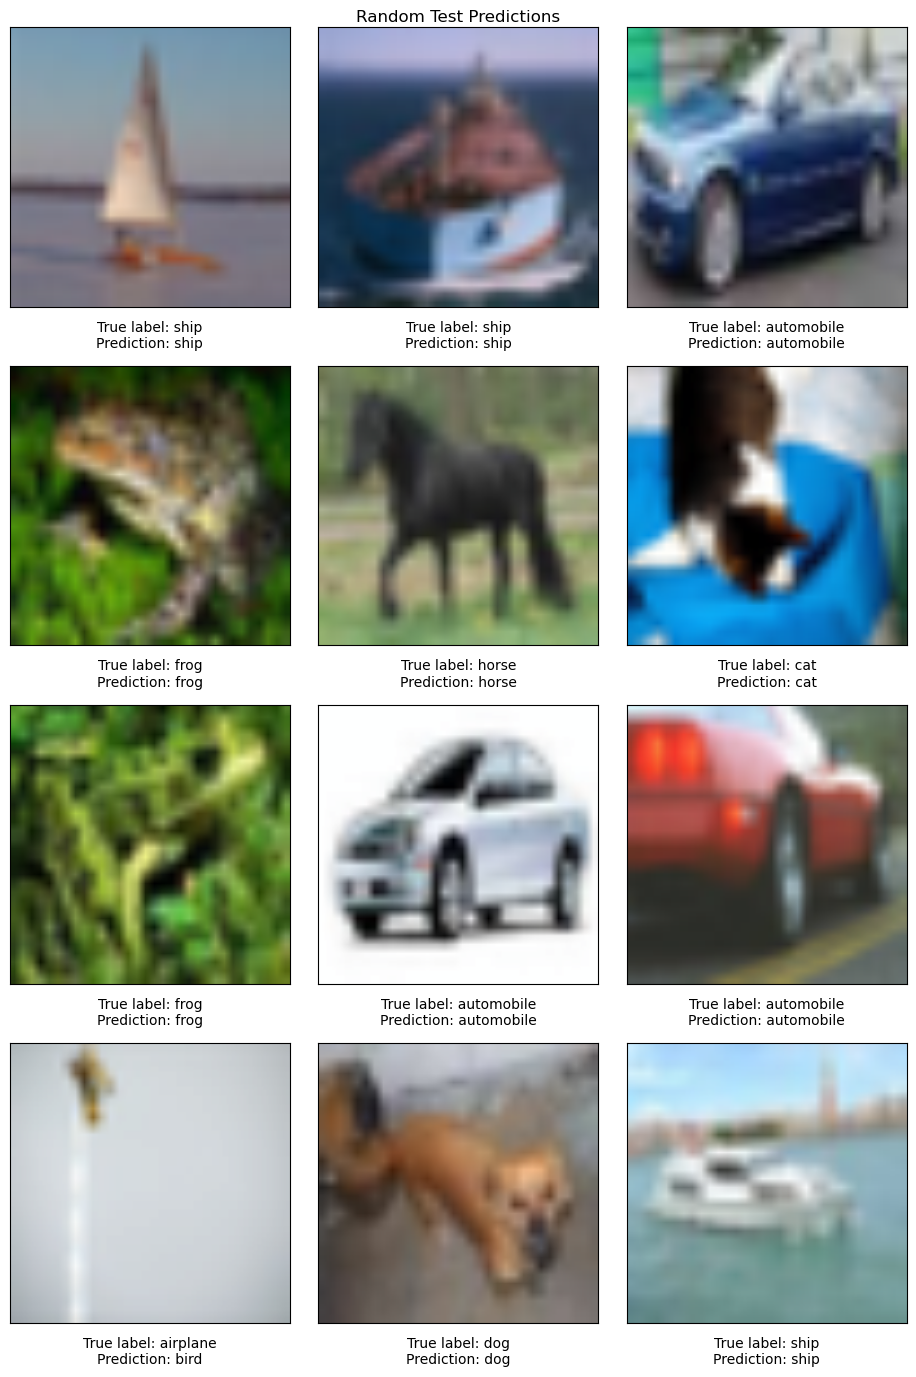

In [ ]:
# Load the best saved model weights
best_model_path = 'best_resnet.pth'
model.load_state_dict(torch.load(best_model_path))

# Run final evaluation on the test set (accuracy, metrics, confusion matrix, etc.)
test_evaluation(model, test_loader, label_mask, IMAGENET_MEAN, IMAGENET_STD) 

## EfficientNet

### Data Loader

In [ ]:
# ImageNet channel-wise mean and std as EfficientNet-B0 was pretrained on ImageNet
# EfficientNet-B0 expects 224x224 inputs (ImageNet standard)
# Validation: resize and normalise only — no augmentation
# shuffle=True for training to prevent the model learning spurious batch-ordering patterns
# shuffle=False for validation & testing: order doesn't affect metrics, and consistency aids debugging

train_transform = train_data_aug(IMAGENET_MEAN, IMAGENET_STD, 224, 16)
val_transform = val_data_aug(IMAGENET_MEAN, IMAGENET_STD, 224)

train_dataset = CIFAR10ArrayDataset(X_train, y_train, transform=train_transform)
val_dataset = CIFAR10ArrayDataset(X_val, y_val, transform=val_transform)
test_dataset = CIFAR10ArrayDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

### Model

In [ ]:
# Replace the classifier head: original outputs 1000 ImageNet classes
# in_features=1280 is EfficientNet-B0's  feature dimension. New head outputs 10 classes for CIFAR-10

def build_efficientnet_fulltune(num_classes=10):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    # All layers remain trainable (requires_grad=True by default)
    in_features = model.classifier[1].in_features  # 1280
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


model = build_efficientnet_fulltune(num_classes=10).to(device)

### Training

In [ ]:
# LR = 1e-4 is intentionally low for full fine-tuning — prevents large gradient updates from destroying pretrained ImageNet features (catastrophic forgetting)
# Label smoothing (eps=0.1): prevents overconfident predictions by softening hard targets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10
best_val_acc, best_epoch = 0.0, 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_path = 'best_efficientnet.pth'

for epoch in range(num_epochs):
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

print(f"Best epoch: {best_epoch}/{num_epochs}, Validation Accuracy: {best_val_acc}")

Epoch 1/10 | Train Loss: 0.5257 | Train Acc: 0.8382 | Val Loss: 0.1656 | Val Acc: 0.9458
Epoch 2/10 | Train Loss: 0.1814 | Train Acc: 0.9401 | Val Loss: 0.1247 | Val Acc: 0.9578
Epoch 3/10 | Train Loss: 0.1276 | Train Acc: 0.9573 | Val Loss: 0.1085 | Val Acc: 0.9627
Epoch 4/10 | Train Loss: 0.0973 | Train Acc: 0.9667 | Val Loss: 0.1069 | Val Acc: 0.9651
Epoch 5/10 | Train Loss: 0.0736 | Train Acc: 0.9747 | Val Loss: 0.1042 | Val Acc: 0.9642
Epoch 6/10 | Train Loss: 0.0606 | Train Acc: 0.9798 | Val Loss: 0.1061 | Val Acc: 0.9658
Epoch 7/10 | Train Loss: 0.0479 | Train Acc: 0.9843 | Val Loss: 0.1074 | Val Acc: 0.9657
Epoch 8/10 | Train Loss: 0.0420 | Train Acc: 0.9860 | Val Loss: 0.1146 | Val Acc: 0.9673
Epoch 9/10 | Train Loss: 0.0378 | Train Acc: 0.9869 | Val Loss: 0.1123 | Val Acc: 0.9664
Epoch 10/10 | Train Loss: 0.0368 | Train Acc: 0.9879 | Val Loss: 0.1115 | Val Acc: 0.9681
Best epoch: 10/10, Validation Accuracy: 0.9681


### Evaluation

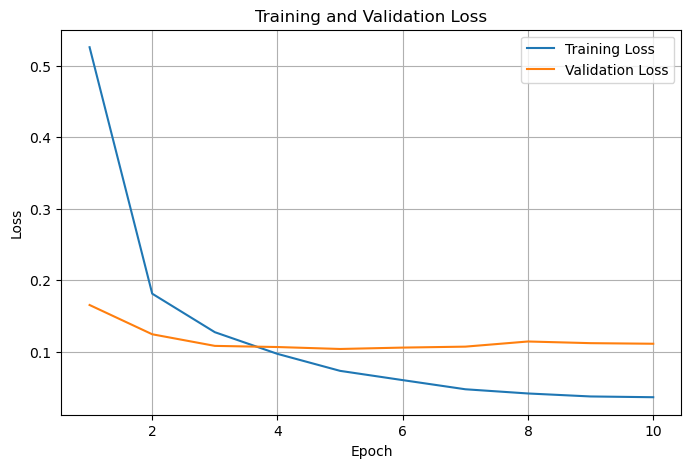

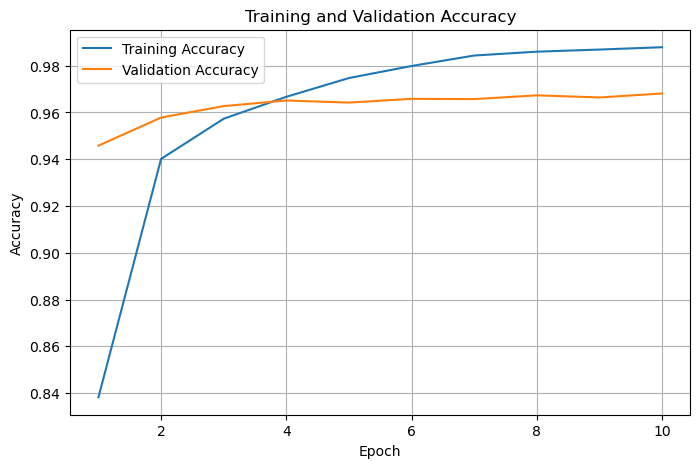

In [62]:
plot_train_val_curve(
    range(1,num_epochs+1), 
    history['train_loss'],
    history['val_loss'], 
    "Loss", 
    "Training and Validation Loss", 
    "efficientnet_loss_curve.png"
)

plot_train_val_curve(
    range(1,num_epochs+1), 
    history['train_acc'],
    history['val_acc'], 
    "Accuracy", 
    "Training and Validation Accuracy", 
    "efficientnet_acc_curve.png"
)

Accuracy: 0.9675
Precision: 0.9678
Recall: 0.9675
F1-score: 0.9675

Classification Report:
              precision    recall  f1-score   support

    airplane       0.97      0.98      0.98      1000
  automobile       0.99      0.96      0.97      1000
        bird       0.98      0.96      0.97      1000
         cat       0.92      0.94      0.93      1000
        deer       0.97      0.98      0.97      1000
         dog       0.94      0.93      0.94      1000
        frog       0.99      0.98      0.98      1000
       horse       0.98      0.98      0.98      1000
        ship       0.98      0.98      0.98      1000
       truck       0.95      0.99      0.97      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



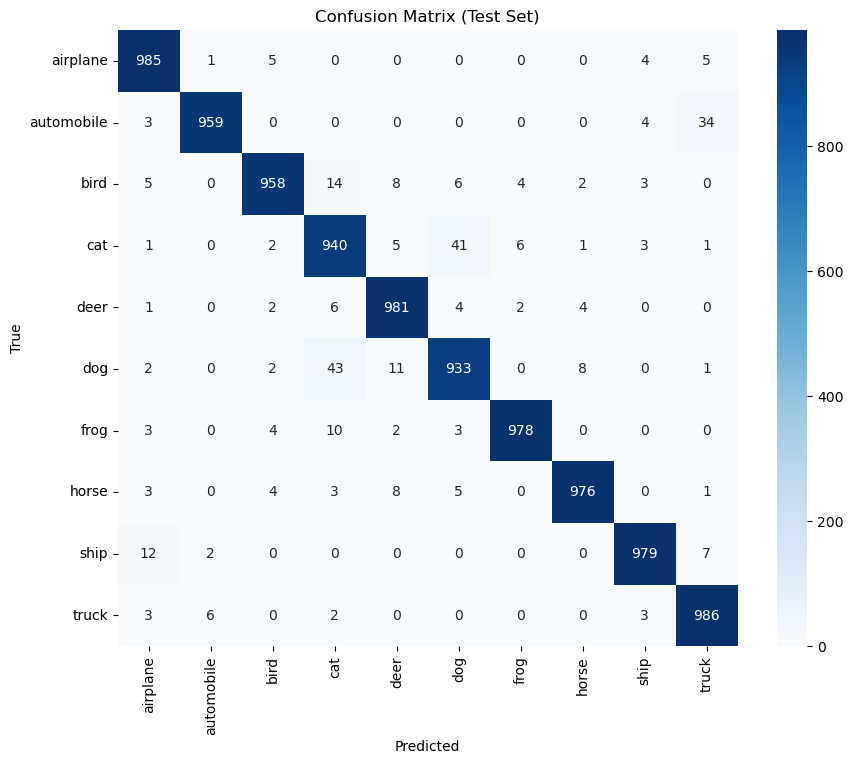

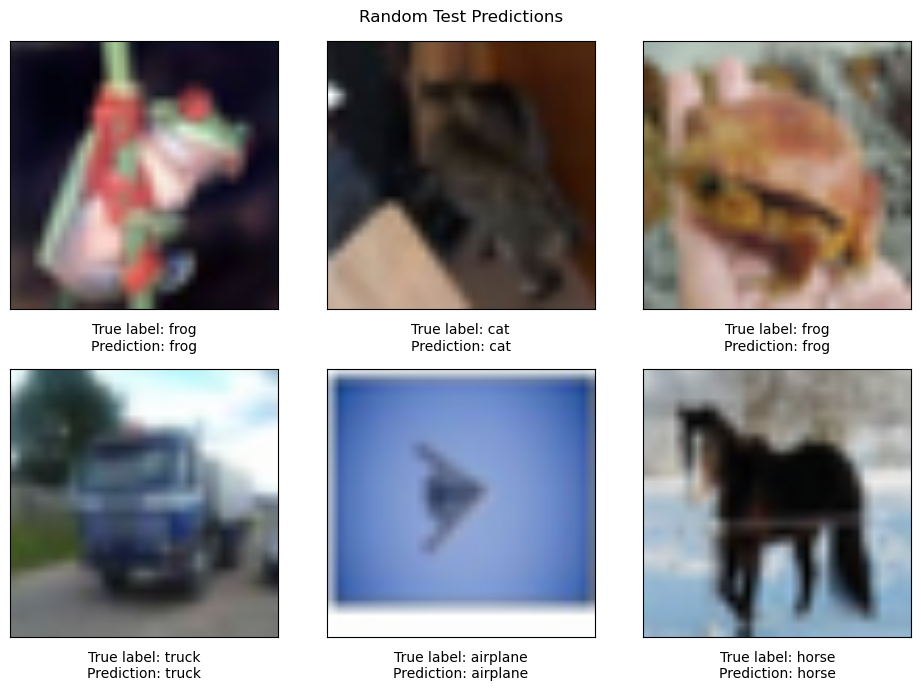

In [ ]:
# Visualisation of test results for the best EfficientNet model
# Truck & airplane has performance issues, likely due to their higher visual complexity and similarity to other classes (e.g., ship, car), which may lead to more misclassifications.
# Random test samples ahow that ground truth labels and predictions are matched across 6 classes, which is a good sign of the model's generalisation ability 

best_model_path = 'best_efficientnet.pth'
model.load_state_dict(torch.load(best_model_path))
test_evaluation(model, test_loader, label_mask, IMAGENET_MEAN, IMAGENET_STD) 